In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Bone Fracture Detection using CNN and OPEN CV**

**Problem Statement**
Build a Convolutional Neural Network (CNN) model to classify X-ray images as:
- Fractured
- Not Fractured

**objective**


Develop an automated fracture detection system using deep learning to assist in medical diagnosis.

In [4]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**checking the if gpu is avible or no**

In [5]:
!ls /content/drive/MyDrive

 20200902_134521.jpg   bone_model.h5	  RoastChicken_RECIPE_080420_37993.jpg
 20200902_135539.jpg   Classroom	  sample2.jpg
 20200902_135547.jpg  'cnn food'	  sample.jpg
 best_food_model.h5   'Colab Notebooks'   vegetable-soup.jpg
 bone		       download.jpg


**Show me all files and folders inside my Google Drive root folder**

In [6]:
!ls /content/drive/MyDrive/bone/Bone_Fracture_Binary_Classification/train

 fractured  'not fractured'


**it gives what kind of classifications avible such as fractured or not fractured bone**

In [7]:
DATA_PATH = "/content/drive/MyDrive/bone/Bone_Fracture_Binary_Classification/train"

###Importing Required Libraries
1. import os :Used to interact with files, folders, and directory paths for dataset handling.
2. numpy as np:Used for numerical operations and converting image data into arrays required for deep learning models.
3. tensorflow (tf) → Deep learning framework used to build, train, and evaluate the CNN model.
4. opencv (cv2) → Used for image preprocessing such as reading images, resizing, reshaping, and converting to grayscale.

In [8]:
import os
import numpy as np
import tensorflow as tf
import cv2

###data path and image size

1. storing the training path in one varaible named data_path
2. image size is 128x128 converts all the images into this size



In [9]:
DATA_PATH = "/content/drive/MyDrive/bone/Bone_Fracture_Binary_Classification/train"
IMG_SIZE = 128

###preprocessing the image
1. reads the image path using cv
2. convert into gray scale
3. resize the image all images to one size
4. normalize the images to 255
5. returns the numpy array format





In [10]:
def preprocess_image(path):
  img = cv2.imread(path)
  img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
  img = img/255.0
  return img

it checks the folders in the train directory

In [11]:
import os

DATA_PATH = "/content/drive/MyDrive/bone/Bone_Fracture_Binary_Classification/train"

print("Folders inside train directory:")
print(os.listdir(DATA_PATH))

Folders inside train directory:
['fractured', 'not fractured']


###Data Loading Function

This function loads images from the dataset directory and assigns class labels.

###Steps Performed:
1. Iterate through each folder inside the dataset directory.
2. Assign labels based on folder name:
   fractured - Label 0
   not fractured - Label 1
3. Preprocess each image using the preprocess_image() function.
4. Store processed images and labels.
5. Convert lists into NumPy arrays for CNN training.

In [12]:
def load_data(directory):
    images = []
    labels = []

    for label in os.listdir(directory):
        folder_path = os.path.join(directory, label)

        if not os.path.isdir(folder_path):
            continue

        # FIXED LABEL LOGIC
        if "not" in label.lower():
            class_num = 1
        else:
            class_num = 0

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            img = preprocess_image(img_path)
            images.append(img)
            labels.append(class_num)

    return np.array(images), np.array(labels)

###calling the function
load_data function is called from training path
1. X- stores the all the processed images
2. y- stores the labels




In [13]:
X,y=load_data(DATA_PATH)
print("dataset loaded sucessfull")

dataset loaded sucessfull


###checking the total samples avible in training data

In [14]:
print("Total samples:", len(X))

Total samples: 9246


###check the shape of X and y

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9246, 128, 128)
y shape: (9246,)


In [16]:
import numpy as np

print("Unique labels:", np.unique(y))
print("Fracture count:", np.sum(y == 0))
print("Normal count:", np.sum(y == 1))

Unique labels: [0 1]
Fracture count: 4606
Normal count: 4640


### train-split and validation
1. importhing the train_test_split from sklearn
2. resize the images which required by cnn
3. data is split into 80% for train and 20% for validation



In [17]:
from sklearn.model_selection import train_test_split
X = X.reshape(-1,IMG_SIZE,IMG_SIZE,1)
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=40)

In [18]:
X = X.reshape(-1, 128, 128, 1)
print(X.shape)

(9246, 128, 128, 1)


###data agumentation
1. this class creates the agumented images during training
2. performs random rotation,horizontal,vertical shifts,zoom up for getting the clear observations of the images



In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

###CNN MODEL
1. seuqntial loads the data layer by layer
2. 1st layer extract the low features using the 32 filters such as edges nd patterns in images
3. relu activation function introduce the non-linearity
4. max pooling reduces the image size and keep th important features and reduces overfitting



In [20]:
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
model = Sequential()
model.add(Conv2D(32,(3,3),
                 activation="relu",
                 input_shape=(128,128,1)))
model.add(MaxPooling2D(2,2))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### second layer of convulution
1. adding with 64 filters for more accuracy of understading about more edges and patterns

In [21]:
model.add(Conv2D(64,(3,3),
                 activation = "relu",
                 input_shape=(128,128,1)))
model.add(MaxPooling2D(2,2))

### flatten layer
1. converts the 3D into 1D vector

In [22]:
model.add(Flatten())

### fully connected dense layer
1. every neuron is connected to every input feature
2. relu adds the non-linearity
3. dropout randomly disable the neurons to prevent the overfitting problem

In [23]:
from tensorflow.keras.layers import Dropout
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))

### final layer output layer
1. dense(1) as it is a binary classsification
2. sigmoid convert the output into probability


In [24]:
model.add(Dense(1,activation='sigmoid'))

### model compilation
1. optimizer controls how weights are updates
2. adaptive moment estimation for learning better rate
3. 0.001 is a standard deafult learning rate for adam
4. binary entropy is used for 2 classifications yes or no
5. metrics accuracy Correct predictions / Total predictions

In [25]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer= Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### model training
1. we use early stop to overcome overfitting problem it will monitor the 3 epochs if there is no any changes the model will stop training
2. model trains 32 images per batch in that way we are training 20 epochs it gives the maximum no of training cycle


In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.6977 - loss: 0.5543 - val_accuracy: 0.9400 - val_loss: 0.2019
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9370 - loss: 0.1661 - val_accuracy: 0.9751 - val_loss: 0.1009
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9773 - loss: 0.0749 - val_accuracy: 0.9778 - val_loss: 0.0725
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9869 - loss: 0.0431 - val_accuracy: 0.9892 - val_loss: 0.0543
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9916 - loss: 0.0267 - val_accuracy: 0.9886 - val_loss: 0.0488
Epoch 6/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9939 - loss: 0.0204 - val_accuracy: 0.9903 - val_loss: 0.0565
Epoch 7/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9967 - loss: 0.0129 - val_accuracy: 0.9892 - val_loss: 0.0653
Epoch 8/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9919 - loss: 0.0174 - val_acc

### loading the test data to test the accuracy

In [27]:
TEST_PATH = "/content/drive/MyDrive/bone/Bone_Fracture_Binary_Classification/test"

###laod the test data
1. load_data(TEST_PATH)loads the test images and labels
2. X_test contains the test images.
3. y_test contains the corresponding labels.
4. reshape() converts the images into the format required by the CNN model (height, width, channels).
5. The print statements confirm that the test data was loaded successfully and show the total number of test samples.

In [28]:
X_test, y_test = load_data(TEST_PATH)

X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("Test data loaded successfully")
print("Number of test samples:", len(X_test))

Test data loaded successfully
Number of test samples: 506


### evaluate the test data
1. the test accuracy was 98% which is very well trained model

In [29]:
loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9778 - loss: 0.0698
Test Accuracy: 0.9762845635414124


### save the model using model.save

In [30]:
model.save("/content/drive/MyDrive/bone_model.h5")

### load the model to apply gradio deployment

In [31]:
model = load_model("/content/drive/MyDrive/bone_model.h5")

### Gradio Prediction Function

This code creates a function that predicts whether an X-ray image shows a bone fracture or a normal bone.

1. The image is converted to grayscale using OpenCV.
2. It is resized to 128 × 128 pixels to match the CNN input size.
3. Pixel values are normalized (0–1)for better model performance.
4. The image is reshaped into the format required by the CNN model.
5. The trained model predicts the probability of fracture.
6. The function returns the prediction label and confidence score.

In [32]:
import gradio as gr
import numpy as np
import cv2

IMG_SIZE = 128

def predict_fracture(image):
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image.astype("float32") / 255.0
    image = image.reshape(1, IMG_SIZE, IMG_SIZE, 1)
    prob = model.predict(image)[0][0]

    if prob > 0.5:
        label = "Normal Bone"
        confidence = prob * 100
    else:
        label = "Fracture Detected"
        confidence = (1 - prob) * 100

    return f"{label}\nConfidence: {confidence:.2f}%"

### Gradio Interface

This code creates a simple web interface using **Gradio**.

1. Users upload an X-ray image.
2. The predict_fracture function analyzes the image.
3. The system displays whether the bone is fractured or normal with a confidence score.
4. interface.launch() runs the application.

In [34]:
# Create interface
interface = gr.Interface(
    fn=predict_fracture,
    inputs=gr.Image(type="numpy"),
    outputs="text",
    title="Bone Fracture Detection System",
    description="Upload an X-ray image to detect fracture with confidence score."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://134468c40430ce5c32.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Confusion Matrix

The confusion matrix shows how many predictions were correct and incorrect.  
It compares the actual labels with the model predictions.

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step


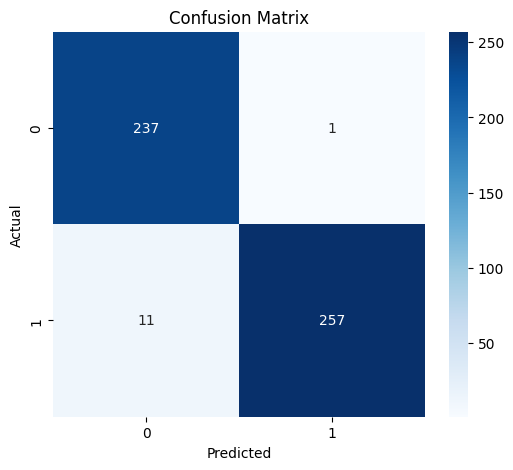

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### F1 Score

F1 Score measures the balance between Precision and Recall.  
It helps evaluate the model performance, especially for classification tasks.

In [36]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9771863117870723


###This feature enables real-time prediction using a webcam.

In [37]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

### preprocess the image
1. resize the image img/255
2. reshape


In [39]:
def preprocess_frame(frame):
    img = cv2.resize(frame, (224,224))
    img = img / 255.0
    img = np.reshape(img, (1,224,224,3))
    return img

### Real-Time Bone Fracture Detection (Webcam)

In this section we capture an image using the webcam and run our trained CNN model to detect whether the bone is fractured or normal.

In [ ]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    img = preprocess_frame(frame)

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        label = "Fracture Detected"
        color = (0,0,255)
    else:
        label = "Normal Bone"
        color = (0,255,0)

    cv2.putText(frame, label, (30,50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1, color, 2)

    cv2.imshow("Bone Fracture Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

## Conclusion

This project demonstrates how deep learning can assist in detecting bone fractures from X-ray images.

Key achievements:

1. CNN based fracture detection
2. Model evaluation using confusion matrix and F1 score
3. Interactive Gradio interface
4. Real-time webcam detection using OpenCV

Future improvements may include:

1. Fracture localization
2. Mobile application deployment
3. Larger medical datasets